In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\ALG\Downloads\archive\India_Menu.csv")

In [3]:
df.head()

,Menu Category,Menu Items,Per Serve Size,Energy (kCal),Protein (g),Total fat (g),Sat Fat (g),Trans fat (g),Cholesterols (mg),Total carbohydrate (g),Total Sugars (g),Added Sugars (g),Sodium (mg)
0,Regular Menu,McVeggie™ Burger,168 g,402.05,10.24,13.83,5.34,0.16,2.49,56.54,7.90,4.49,706.13
1,Regular Menu,McAloo Tikki Burger®,146 g,339.52,8.50,11.31,4.27,0.20,1.47,50.27,7.05,4.07,545.34
2,Regular Menu,McSpicy™ Paneer Burger,199 g,652.76,20.29,39.45,17.12,0.18,21.85,52.33,8.35,5.27,1074.58
3,Regular Menu,Spicy Paneer Wrap,250 g,674.68,20.96,39.10,19.73,0.26,40.93,59.27,3.50,1.08,1087.46
4,Regular Menu,American Veg Burger,177 g,512.17,15.30,23.45,10.51,0.17,25.24,56.96,7.85,4.76,1051.24


In [4]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col]=df[col].fillna(df[col].median())

In [5]:
num=df.select_dtypes(include='number')

In [6]:
num.drop(columns=['Sat Fat (g)','Trans fat (g)','Added Sugars (g)'],errors='ignore')

,Energy (kCal),Protein (g),Total fat (g),Cholesterols (mg),Total carbohydrate (g),Total Sugars (g),Sodium (mg)
0,402.05,10.24,13.83,2.49,56.54,7.90,706.13
1,339.52,8.50,11.31,1.47,50.27,7.05,545.34
2,652.76,20.29,39.45,21.85,52.33,8.35,1074.58
3,674.68,20.96,39.10,40.93,59.27,3.50,1087.46
4,512.17,15.30,23.45,25.24,56.96,7.85,1051.24
...,...,...,...,...,...,...,...
136,11.23,0.08,23.45,0.08,2.63,2.33,71.05
137,86.40,0.00,0.00,0.30,21.60,16.20,15.00
138,51.03,3.06,3.99,13.43,0.72,0.54,178.95
139,45.08,1.47,1.00,2.00,7.55,2.54,0.04


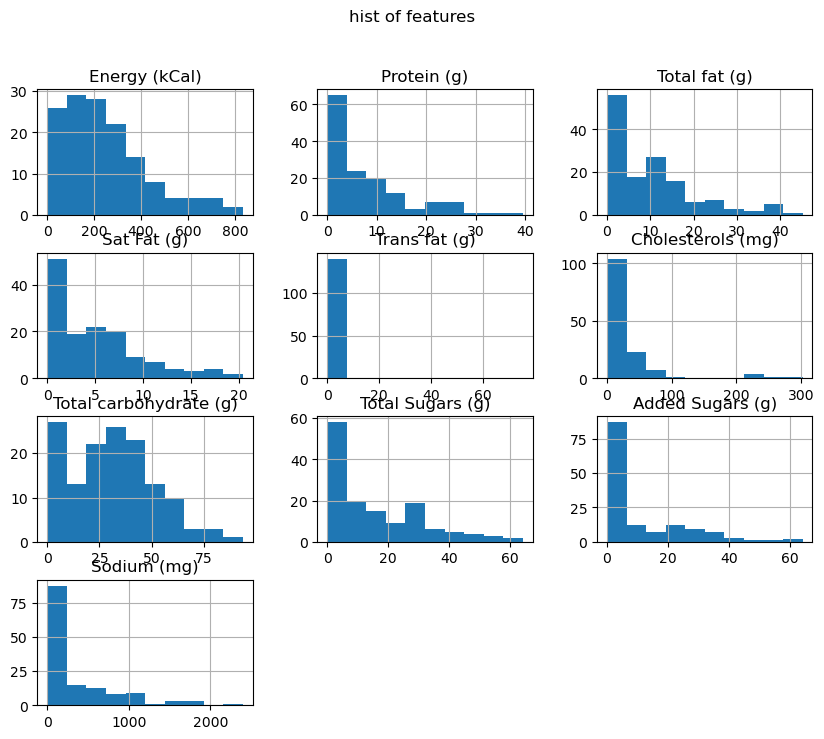

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
num.hist(figsize=(10,8))
plt.suptitle("hist of features")
plt.show()


iqr_col=['Sodium (mg)','Cholesterols (mg)']
for col in iqr_col:
   q1=num[col].quantile(0.25)
   q3=num[col].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
num[col]=num[col].clip(upper=upper)
log_col=['Total fat (g)','Total Sugars (g)','Protein (g)']
for col in log_col:
    num[col]=np.log1p(num[col])


In [8]:
num.skew()

Energy (kCal)              0.976921
Protein (g)               -0.075646
Total fat (g)             -0.340021
Sat Fat (g)                1.038435
Trans fat (g)             11.867997
Cholesterols (mg)          1.317151
Total carbohydrate (g)     0.364824
Total Sugars (g)          -0.247441
Added Sugars (g)           1.579746
Sodium (mg)                1.865073
dtype: float64

In [9]:
target='Energy (kCal)'


In [10]:
X=num.drop(columns=[target])
y=num[target]

In [11]:
y.head()


0    402.05
1    339.52
2    652.76
3    674.68
4    512.17
Name: Energy (kCal), dtype: float64

In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [13]:
corr=num.corr()

<Axes: >

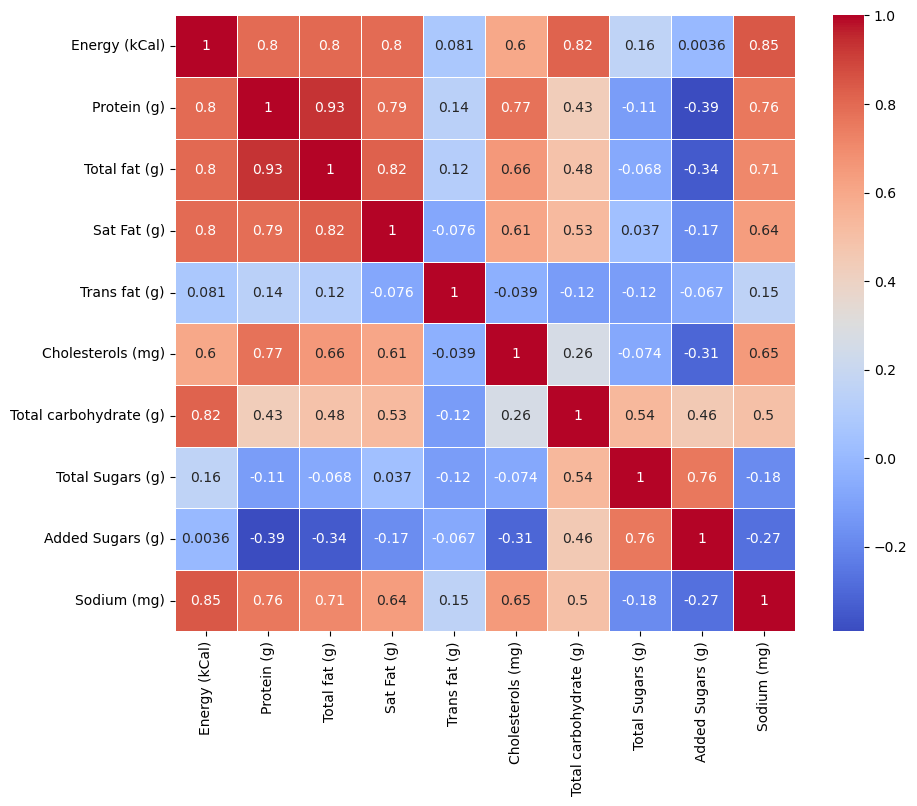

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,
             cmap='coolwarm',
             annot=True,
             linewidths=0.5
)

In [15]:
df_encoded=pd.get_dummies(df,columns=['Menu Category','Menu Items'])
print(df_encoded)

    Per Serve Size  Energy (kCal)  Protein (g)  Total fat (g)  Sat Fat (g)  \
0            168 g         402.05        10.24          13.83         5.34   
1            146 g         339.52         8.50          11.31         4.27   
2            199 g         652.76        20.29          39.45        17.12   
3            250 g         674.68        20.96          39.10        19.73   
4            177 g         512.17        15.30          23.45        10.51   
..             ...            ...          ...            ...          ...   
136            8 g          11.23         0.08          23.45         0.00   
137           30 g          86.40         0.00           0.00         0.00   
138           14 g          51.03         3.06           3.99         2.89   
139           40 g          45.08         1.47           1.00         0.22   
140         180 ml          72.25         0.65           0.02         0.02   

     Trans fat (g)  Cholesterols (mg)  Total carbohydrate (g)  

In [16]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.ensemble import RandomForestRegressor

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestRegressor()
model.fit(X_train,y_train)
pre=model.predict(X_test)
print(model.score(X_test,y_test))

0.9051047453570698


In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,pre)
mse=mean_squared_error(y_test,pre)


In [19]:
print(mae)
print("mse:",mse)

31.472931034482805
mse: 4015.3008876813833


In [20]:
score=cross_val_score(model,X,y,cv=5,scoring='r2')
print("scores:",score.mean())
print(score)
print(score.std())

scores: 0.8328192484977762
[0.92033065 0.95061116 0.9712209  0.96431781 0.35761573]
0.2382429250827185


In [21]:
r2=r2_score(y_test,pre)
print("r2_score:",r2)

r2_score: 0.9051047453570698


In [22]:
num.duplicated().sum()

np.int64(1)

In [23]:
num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Energy (kCal)           141 non-null    float64
 1   Protein (g)             141 non-null    float64
 2   Total fat (g)           141 non-null    float64
 3   Sat Fat (g)             141 non-null    float64
 4   Trans fat (g)           141 non-null    float64
 5   Cholesterols (mg)       141 non-null    float64
 6   Total carbohydrate (g)  141 non-null    float64
 7   Total Sugars (g)        141 non-null    float64
 8   Added Sugars (g)        141 non-null    float64
 9   Sodium (mg)             141 non-null    float64
dtypes: float64(10)
memory usage: 11.1 KB


In [24]:
num.describe()

,Energy (kCal),Protein (g),Total fat (g),Sat Fat (g),Trans fat (g),Cholesterols (mg),Total carbohydrate (g),Total Sugars (g),Added Sugars (g),Sodium (mg)
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,244.635461,1.616292,1.816285,4.997589,0.687163,18.957092,31.190284,2.208315,10.336950,360.574504
std,185.554837,1.091417,1.219110,4.900451,6.326136,23.011747,20.602044,1.211908,14.283388,471.799303
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,116.360000,0.500775,0.378436,0.280000,0.060000,1.510000,15.740000,1.202972,0.000000,44.530000
50%,219.360000,1.756132,2.171337,4.270000,0.150000,8.390000,30.820000,2.318458,3.640000,152.025000
75%,339.520000,2.474856,2.718660,7.280000,0.220000,31.110000,46.000000,3.330417,19.230000,530.540000
max,834.360000,3.700561,3.832547,20.460000,75.260000,75.510000,93.840000,4.177766,64.220000,2399.490000


In [25]:
dup=num.columns[num.columns.duplicated()]
print(dup)

Index([], dtype='object')


In [26]:
importance=model.feature_importances_
fea=pd.Series(importance,index=X.columns)
print(fea.sort_values(ascending=False))

Total fat (g)             0.586598
Sodium (mg)               0.127033
Total carbohydrate (g)    0.105863
Protein (g)               0.092163
Sat Fat (g)               0.052523
Added Sugars (g)          0.014241
Total Sugars (g)          0.013794
Cholesterols (mg)         0.004933
Trans fat (g)             0.002853
dtype: float64


In [27]:
from sklearn.inspection import permutation_importance

In [28]:
permutation=permutation_importance(model,X_test,y_test,n_repeats=10)
imp=pd.Series(permutation.importances_mean,index=X.columns)
print(imp.sort_values(ascending=False))

Total fat (g)             0.592495
Total carbohydrate (g)    0.141686
Protein (g)               0.040900
Sodium (mg)               0.032885
Sat Fat (g)               0.012429
Total Sugars (g)          0.010945
Added Sugars (g)          0.008280
Trans fat (g)             0.001671
Cholesterols (mg)        -0.000346
dtype: float64


In [29]:
num.isnull().sum()

Energy (kCal)             0
Protein (g)               0
Total fat (g)             0
Sat Fat (g)               0
Trans fat (g)             0
Cholesterols (mg)         0
Total carbohydrate (g)    0
Total Sugars (g)          0
Added Sugars (g)          0
Sodium (mg)               0
dtype: int64

In [30]:
num.shape

(141, 10)

In [31]:
num['macros']=num['Total carbohydrate (g)']+num['Protein (g)']+num['Total fat (g)']


In [32]:
num=num.drop(columns=['Sat Fat (g)','Trans fat (g)','Cholesterols (mg)','Total Sugars (g)','Sodium (mg)','Added Sugars (g)'])

In [33]:
x_new=num.drop(columns='Energy (kCal)')
y_new=num['Energy (kCal)']

In [34]:
x_new.columns

Index(['Protein (g)', 'Total fat (g)', 'Total carbohydrate (g)', 'macros'], dtype='object')

In [35]:
y_new.head()

0    402.05
1    339.52
2    652.76
3    674.68
4    512.17
Name: Energy (kCal), dtype: float64

In [36]:
x_new_train,x_new_test,y_new_train,y_new_test=train_test_split(x_new,y_new,test_size=0.2,random_state=42)

In [37]:
model=RandomForestRegressor()
model.fit(x_new_train,y_new_train)
pre=model.predict(x_new_test)
print(model.score(x_new_test,y_new_test))

0.9010179584356003


In [38]:
score=cross_val_score(model,x_new,y_new,cv=5,scoring='r2')
print("scores:",score.mean())

scores: 0.8716056778850183


In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lr=LinearRegression()
lr.fit(x_new_train,y_new_train)
predict=lr.predict(x_new_test)
print("score:",r2_score(y_new_test,predict))

score: 0.9104446947114203


In [41]:
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(lr,x_new,y_new,cv=kfold,scoring='r2')
print("scores:",score.mean())

scores: 0.8879243471312173


In [42]:
!pip install xgboost

In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold

In [44]:
model= XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
model.fit(x_new_train,y_new_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
kfold=KFold(n_splits=5,shuffle=True,random_state=42)
score=cross_val_score(model,x_new,y_new,cv=kfold)
print(score.mean())

0.9559911679199085


In [46]:
scores=cross_val_score(model,x_new,y_new,cv=kfold,scoring='r2')

In [47]:
print(scores)
print(scores.mean())
print(scores.std())

[0.87646334 0.96939239 0.96724285 0.98145473 0.98540253]
0.9559911679199085
0.04035911323471441


In [48]:
import joblib
joblib.dump(model,'mcd_model.pkl')

['mcd_model.pkl']

In [49]:
loaded_model=joblib.load('mcd_model.pkl')